In [1]:
%load_ext autoreload
%autoreload 2
from trees.experiment import Experiment
from trees.topk import *

exp = Experiment("Top-K Algorithm", k=[3], exp_name="exhaustive", user_iterations=10, topk_methods=exhaustive_comparison)

2025-02-27 12:53:20.497 | INFO     | trees.experiment:__init__:72 - Generating data: {'n': 100000, 'p': 10, 'sigma': 3.0, 'seed': 0, 'mode': 2}
2025-02-27 12:54:56.862 | INFO     | trees.experiment:__init__:79 - 	 [Pretrained] CF - Offline time: 0:01:36.261603
100%|██████████| 20708500/20708500 [02:44<00:00, 125660.91it/s]
2025-02-27 12:57:44.342 | INFO     | trees.topk:scan:429 - Valid subgroups: 2654 out of 3558
100%|██████████| 20708500/20708500 [01:18<00:00, 262918.48it/s]
2025-02-27 12:59:04.076 | INFO     | trees.topk:scan:458 - Valid subgroups: 2654 out of 3558
100%|██████████| 20708500/20708500 [02:46<00:00, 124511.20it/s]
2025-02-27 13:03:09.675 | INFO     | trees.topk:scan:429 - Valid subgroups: 1825 out of 3558
100%|██████████| 20708500/20708500 [01:18<00:00, 265203.43it/s]
2025-02-27 13:04:28.849 | INFO     | trees.topk:scan:458 - Valid subgroups: 1825 out of 3558
100%|██████████| 20708500/20708500 [02:44<00:00, 125696.36it/s]
2025-02-27 13:08:32.960 | INFO     | trees.topk

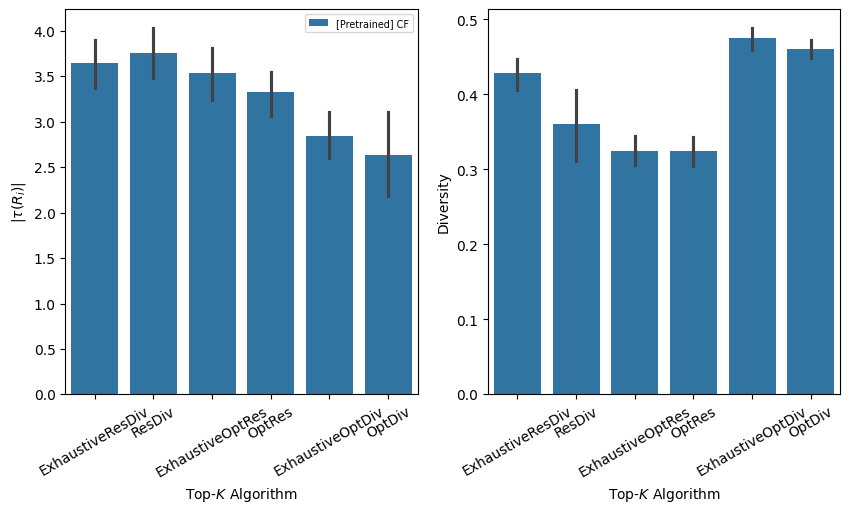

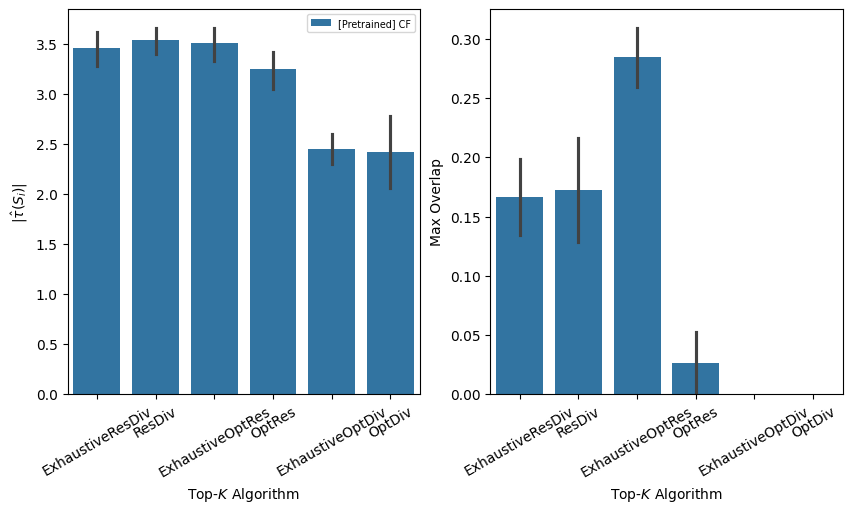

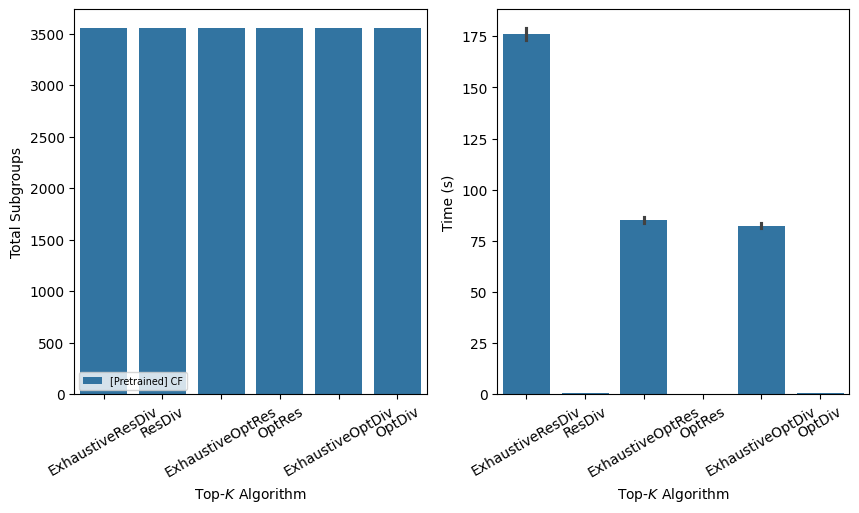

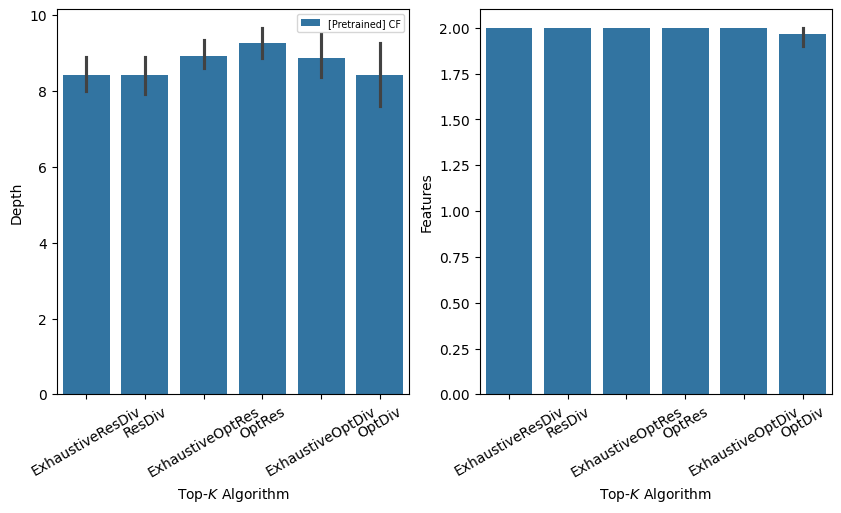

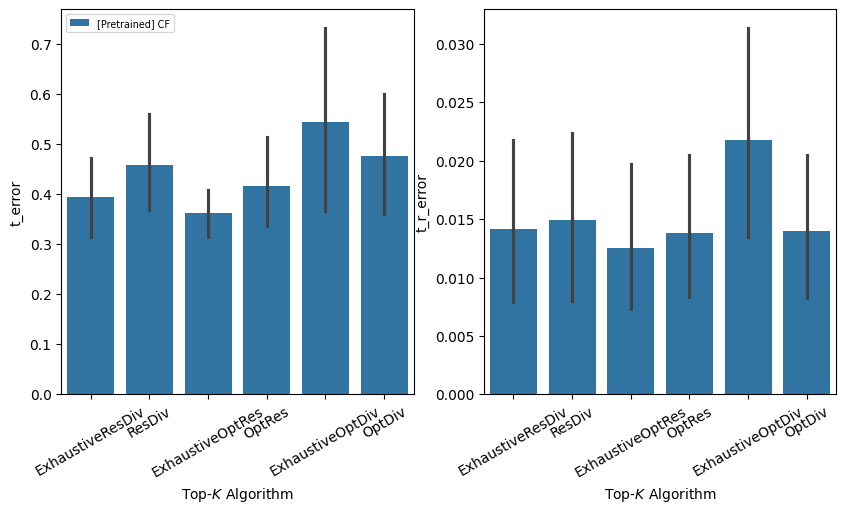

In [2]:
exp.plots(hue='estimator', rotation=30)

In [9]:
def compare_to_exhaustive(alg, exhaustive):
    s = exp.scores
    CATE = round(s[s['Top-K Algorithm']==alg]['t'].mean()/s[s['Top-K Algorithm']==exhaustive]['t'].mean(), 2)
    diversity = round(s[s['Top-K Algorithm']==alg]['Diversity'].mean()/s[s['Top-K Algorithm']==exhaustive]['Diversity'].mean(),2)
    print(f"{alg} % Exhaustive {CATE=}, {diversity=}")
    return CATE, diversity

OptRes % Exhaustive CATE=0.94, diversity=1.0
OptDiv % Exhaustive CATE=0.93, diversity=0.97
ResDiv % Exhaustive CATE=1.03, diversity=0.84


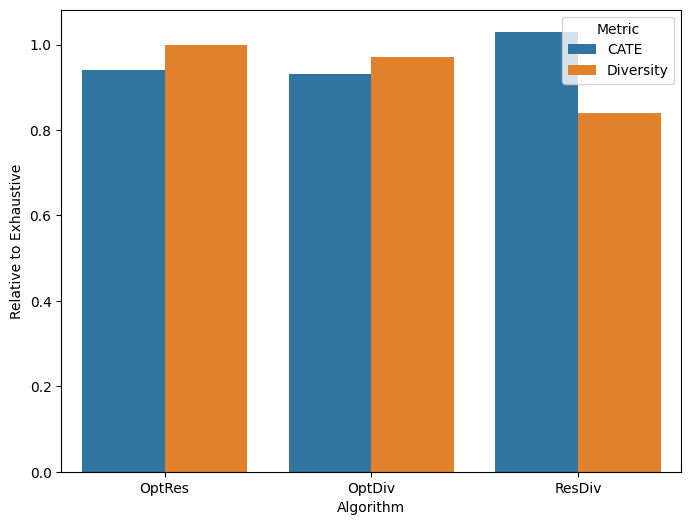

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get the values
CATE, diversity = compare_to_exhaustive("OptRes", "ExhaustiveOptRes")
CATE_OptDiv, diversity_OptDiv = compare_to_exhaustive("OptDiv", "ExhaustiveOptDiv")
CATE_ResDiv, diversity_ResDiv = compare_to_exhaustive("ResDiv", "ExhaustiveResDiv")

# Create a dataframe for plotting
plot_data = pd.DataFrame({
    'Algorithm': ['OptRes', 'OptRes', 'OptDiv', 'OptDiv', 'ResDiv', 'ResDiv'],
    'Relative to Exhaustive': [CATE, diversity, CATE_OptDiv, diversity_OptDiv, CATE_ResDiv, diversity_ResDiv],
    'Metric': ['CATE', 'Diversity', 'CATE', 'Diversity', 'CATE', 'Diversity']
})

# Plot the data
plt.figure(figsize=(8, 6))
sns.barplot(x='Algorithm', y='Relative to Exhaustive', hue='Metric', data=plot_data)
# plt.title('Relative Performance to Exhaustive Algorithms')
plt.show() 